# 00. Retake: Stack de Python para el curso
**Dr. rer. nat. Jose Ivan Campos Rozo**  
*Observatorio Astronómico Nacional - Universidad Nacional de Colombia*

## Repaso del Stack Científico:
* NumPy — arreglos y álgebra lineal
* SciPy — integración, optimización, EDOs, interpolación
* Matplotlib — visualización
* Astropy — unidades, constantes, coordenadas, tablas
* SunPy — datos de física solar

## 1. NumPy
El arreglo `ndarray` es la base del cómputo numérico y operaciones vectorizadas.

In [1]:
import numpy as np

t = np.linspace(0, 10, 100)
flujo = np.exp(-((t - 5)**2) / 2)

print(t[0:5])
print(flujo[0:5])
print('maximo:', flujo.max(), 'en t =', t[flujo.argmax()])

[0.        0.1010101 0.2020202 0.3030303 0.4040404]
[3.72665317e-06 6.14389891e-06 1.00262383e-05 1.61957424e-05
 2.58959932e-05]
maximo: 0.9987254328882499 en t = 4.94949494949495


## 2. SciPy
Algoritmos numéricos optimizados: `scipy.integrate` y `scipy.optimize`.

In [2]:
from scipy import integrate, optimize

f = lambda x: np.exp(-x**2)
resultado, error_est = integrate.quad(f, 0, np.inf)
print('integral =', resultado, '  error estimado =', error_est)

raiz = optimize.brentq(lambda x: np.cos(x) - x, 0, 1)
print('raiz =', raiz)

integral = 0.8862269254527579   error estimado = 7.101318390472462e-09
raiz = 0.7390851332151559


## 3. Matplotlib
Librería estándar para generación de gráficos científicos.

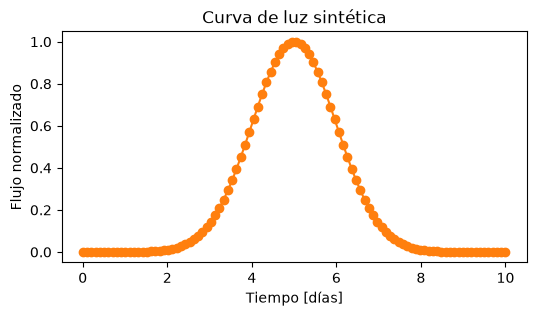

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t, flujo, 'o-', color='tab:orange')
ax.set_xlabel('Tiempo [días]')
ax.set_ylabel('Flujo normalizado')
ax.set_title('Curva de luz sintética')
plt.show()

## 4. Astropy
Manejo de unidades físicas, constantes y coordenadas celestes.

In [4]:
import astropy.units as u
from astropy import constants as const
from astropy.coordinates import SkyCoord

masa_sol = 1.0 * u.Msun
radio_sol = 1.0 * const.R_sun
densidad = (masa_sol / (4/3 * np.pi * radio_sol**3)).to(u.g / u.cm**3)
print('densidad media del Sol:', densidad)

try:
    betelgeuse = SkyCoord.from_name('Betelgeuse')
    print(betelgeuse.ra, betelgeuse.dec)
except Exception as e:
    print("Consulta a CDS requiere conexión a internet.")

densidad media del Sol: 1.4097798243075257 g / cm3
88d47m34.580364s 7d24m25.4304s


## 5. SunPy
Paquete para física solar e imágenes `sunpy.map`.

In [ ]:
import sunpy.map
import sunpy.data.sample

try:
    mapa = sunpy.map.Map(sunpy.data.sample.AIA_171_IMAGE)
    fig = plt.figure()
    ax = fig.add_subplot(projection=mapa)
    mapa.plot(axes=ax)
    plt.show()
except Exception as e:
    print("Descarga de datos de muestra requiere conexión a internet.")

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

AIA20110607_063302_0171_lowres.fits:   0%|          | 0.00/973k [00:00<?, ?B/s]

Descarga de datos de muestra requiere conexión a internet.


## 6. Funciones, Clases y Archivos
Estructuración de código y E/S de datos con NumPy.

In [ ]:
def energia_cinetica(masa, velocidad):
    """Energia cinetica no relativista."""
    return 0.5 * masa * velocidad**2

class Particula:
    def __init__(self, masa, posicion, velocidad):
        self.masa = masa
        self.posicion = np.array(posicion, dtype=float)
        self.velocidad = np.array(velocidad, dtype=float)

    def energia_cinetica(self):
        return 0.5 * self.masa * np.dot(self.velocidad, self.velocidad)

p = Particula(masa=1.0, posicion=[0, 0], velocidad=[1, 2])
print(p.energia_cinetica())

# Escribir y leer archivos
datos = np.column_stack([t, flujo])
np.savetxt('curva_de_luz.txt', datos, fmt='%.5f', header='tiempo[dias]  flujo_normalizado')

datos_leidos = np.loadtxt('curva_de_luz.txt')
print(datos_leidos[:3])